<a href="https://colab.research.google.com/github/NataliiaFakas/TFG_BMW/blob/main/1_Variables_macroecon%C3%B3micas_y_Ventas_BMW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicción de ventas de coches de BMW**

# Introducción

---

En el presente cuaderno se lleva a cabo el análisis exploratorio y la preparación de
las variables macroeconómicas empleadas como predictores en el modelo de predicción
de ventas de vehículos de la marca BMW.

El comportamiento de la demanda en el sector automovilístico se encuentra
estrechamente ligado al contexto económico general, por lo que resulta necesario
incorporar al modelo un conjunto de indicadores macroeconómicos capaces de capturar
dicha relación.

A lo largo de este documento se describe cada una de las variables consideradas,
detallando:

- Su definición y relevancia económica.
- La fuente oficial de los datos.
- El tratamiento previo aplicado a la información.
- La justificación de su inclusión en el modelo predictivo.

---

## Objetivo

El objetivo de este cuaderno es, por tanto, presentar y justificar la selección de
las variables macroeconómicas incluidas en el estudio, así como documentar el proceso
de obtención, limpieza y preprocesamiento de los datos, garantizando la
reproducibilidad del análisis.

Como resultado, se obtiene un conjunto de datos preparado para su integración en el
dataset final, que será utilizado posteriormente para el entrenamiento y la
evaluación del modelo predictivo de ventas de BMW.


# Ventas de vehículos

---

Para la variable objetivo (variable a predecir), `Ventas_BMW_Unidades`, se ha
seleccionado el número de matriculaciones de la marca BMW en Europa, obtenido a
partir de los BMW Group Annual Reports y de los comunicados oficiales de resultados
anuales publicados por la compañía.

---

## Fuentes: BMW Group Annual Reports

La siguiente tabla recoge, para cada ejercicio, el informe anual utilizado como
fuente de los datos de matriculaciones:

| Año  | Informe                                                      |
|------|---------------------------------------------------------------|
| 2005 | BMW Group Annual Report 2005                                  |
| 2006 | BMW Group Annual Report 2006                                  |
| 2007 | BMW Group Annual Report 2007                                  |
| 2008 | BMW Group Annual Report 2008 *(Investor Relations Archive)*   |
| 2009 | BMW Group Annual Report 2009 *(Investor Relations Archive)*   |
| 2010 | BMW Group Annual Report 2010 *(Investor Relations Archive)*   |
| 2011 | BMW Group Annual Report 2011 *(Investor Relations Archive)*   |
| 2012 | BMW Group Annual Report 2012 *(Investor Relations Archive)*   |
| 2013 | BMW Group Annual Report 2013 *(Investor Relations Archive)*   |
| 2014 | BMW Group Annual Report 2014 *(Investor Relations Archive)*   |
| 2015 | BMW Group Annual Report 2015 *(Investor Relations Archive)*   |
| 2016 | BMW Group Annual Report 2016 *(Investor Relations Archive)*   |
| 2017 | BMW Group Annual Report 2017 *(Investor Relations Archive)*   |
| 2018 | BMW Group Annual Report 2018 *(Investor Relations Archive)*   |
| 2019 | BMW Group Annual Report 2019 *(Investor Relations Archive)*   |
| 2020 | BMW Group Report 2020                                         |
| 2021 | BMW Group Report 2021 *(Investor Relations Archive)*           |
| 2022 | BMW Group Report 2022 *(Investor Relations Archive)*           |
| 2023 | BMW Group Report 2023 *(Investor Relations Archive)*           |
| 2024 | BMW Group Report 2024                                         |
| 2025 | BMW Group Report 2025                                         |

A continuación se muestra la tabla completa con los datos de matriculaciones de BMW
extraídos de las fuentes anteriores:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

ruta = "/content/drive/MyDrive/TFG_BMW/datasets/ventas_bmw.csv"
df = pd.read_csv(ruta)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df)

,Año,Ventas_BMW_Unidades
0,2005,1126768
1,2006,1185088
2,2007,1276793
3,2008,1202239
4,2009,1068770
5,2010,1224280
6,2011,1380384
7,2012,1540085
8,2013,1655138
9,2014,1811719


## Análisis exploratorio de las ventas de BMW

A continuación, se llevará a cabo un **análisis exploratorio** de la serie histórica de **matriculaciones de vehículos BMW en Europa**, con el objetivo de identificar la **tendencia general**, la **variabilidad interanual** y los **principales acontecimientos económicos** que hayan podido influir en la evolución de las ventas a lo largo del período de estudio.

Como primer paso, se calcularán la **variación absoluta** y la **variación porcentual interanual** de las matriculaciones. Estas métricas permitirán identificar de forma más clara los años en los que se produjeron incrementos o descensos significativos en las ventas, facilitando posteriormente su interpretación en relación con el contexto macroeconómico y los acontecimientos relevantes ocurridos durante cada ejercicio.

Y también se calculan aquellos estadísticos que puedan resultar interesantes mediante la función describe()

---

In [7]:
df["Ventas_BMW_Unidades"].describe()
import matplotlib.pyplot as plt
display(df["Ventas_BMW_Unidades"].describe())

,Ventas_BMW_Unidades
count,2.100000e+01
mean,1.748981e+06
std,4.319958e+05
min,1.068770e+06
25%,1.276793e+06
50%,1.905234e+06
75%,2.125026e+06
max,2.253835e+06


In [5]:

df["Variacion_Absoluta"] = df["Ventas_BMW_Unidades"].diff()
df["Variacion_Porcentual"] = df["Ventas_BMW_Unidades"].pct_change() * 100

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df)

,Año,Ventas_BMW_Unidades,Variacion_Absoluta,Variacion_Porcentual
0,2005,1126768,NaN,NaN
1,2006,1185088,58320.0,5.175866
2,2007,1276793,91705.0,7.738244
3,2008,1202239,-74554.0,-5.839161
4,2009,1068770,-133469.0,-11.101703
5,2010,1224280,155510.0,14.550371
6,2011,1380384,156104.0,12.750678
7,2012,1540085,159701.0,11.569317
8,2013,1655138,115053.0,7.470562
9,2014,1811719,156581.0,9.460299


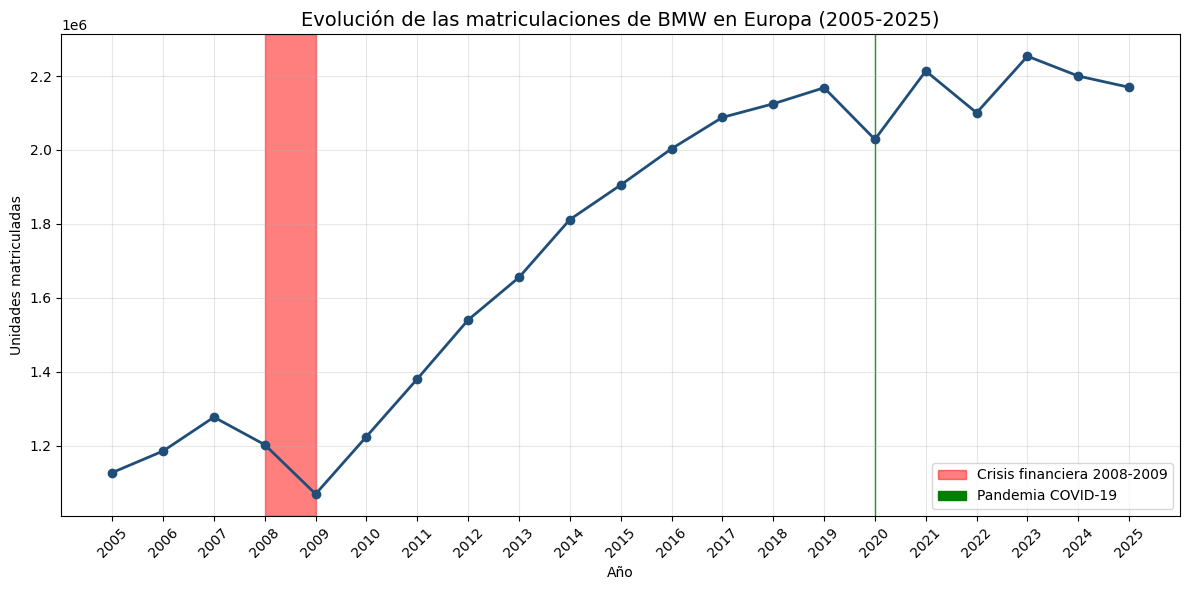

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df["Año"], df["Ventas_BMW_Unidades"], marker="o", linewidth=2, color="#1F4E79")
plt.title("Evolución de las matriculaciones de BMW en Europa (2005-2025)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Unidades matriculadas")
plt.grid(alpha=0.3)
plt.xticks(df["Año"], rotation=45)

plt.axvspan(2008, 2009, color="red", alpha=0.5, label="Crisis financiera 2008-2009")
plt.axvspan(2020, 2020, color="green", alpha=1, label="Pandemia COVID-19")
plt.legend()
plt.tight_layout()
plt.show()

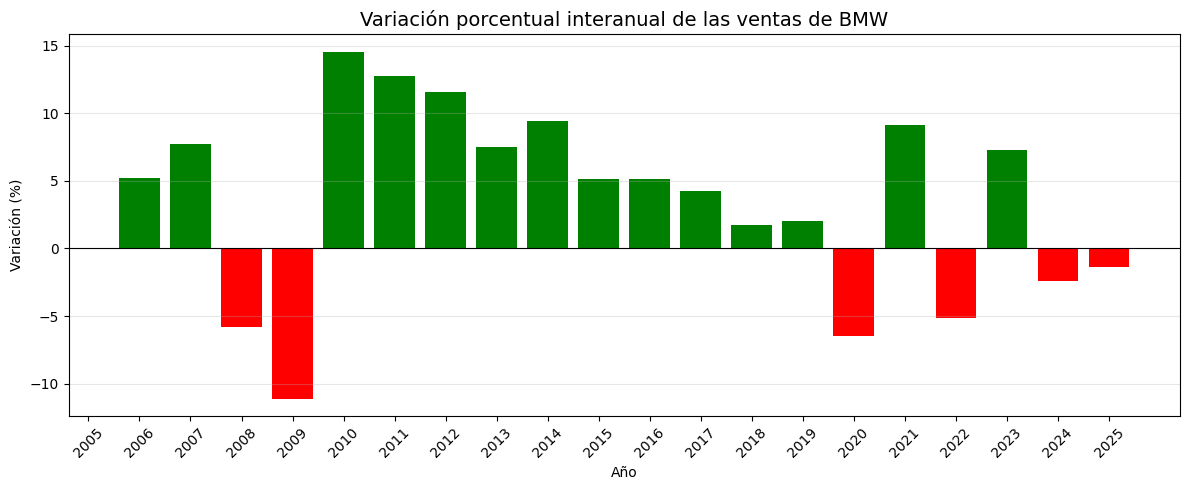

In [ ]:
plt.figure(figsize=(12, 5))
colors = ["green" if x >= 0 else "red" for x in df["Variacion_Porcentual"].fillna(0)]
plt.bar(df["Año"], df["Variacion_Porcentual"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Variación porcentual interanual de las ventas de BMW", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Variación (%)")
plt.xticks(df["Año"], rotation=45)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
# Identificación de máximos, mínimos y variaciones extremas
año_max = df.loc[df["Ventas_BMW_Unidades"].idxmax()]
año_min = df.loc[df["Ventas_BMW_Unidades"].idxmin()]
mayor_caida = df.loc[df["Variacion_Porcentual"].idxmin()]
mayor_subida = df.loc[df["Variacion_Porcentual"].idxmax()]

print(f"Año con más ventas: {int(año_max['Año'])} ({int(año_max['Ventas_BMW_Unidades'])} unidades)")
print(f"Año con menos ventas: {int(año_min['Año'])} ({int(año_min['Ventas_BMW_Unidades'])} unidades)")
print(f"Mayor caída interanual: {int(mayor_caida['Año'])} ({mayor_caida['Variacion_Porcentual']:.2f}%)")
print(f"Mayor subida interanual: {int(mayor_subida['Año'])} ({mayor_subida['Variacion_Porcentual']:.2f}%)")

Año con más ventas: 2023 (2253835 unidades)
Año con menos ventas: 2009 (1068770 unidades)
Mayor caída interanual: 2009 (-11.10%)
Mayor subida interanual: 2010 (14.55%)


## Análisis de la evolución anual de las matriculaciones de BMW en Europa (2005–2025)

A partir de la evolución de las 21 observaciones de matriculaciones anuales y de las tasas de variación interanual, pueden destacarse los siguientes periodos:

---

### Crisis financiera internacional (2008–2009)

Entre **2008 y 2009** se observa el mayor descenso continuado de toda la serie histórica. En 2008 las matriculaciones disminuyen un **5,84%**, mientras que al año siguiente, la caída alcanza el **11,10%**, situándose en **1.068.770 vehículos**, el valor mínimo del periodo analizado.

Dicho comportamiento coincide con el impacto de la crisis financiera mundial iniciada en 2008, el cual provocó una fuerte contracción del consumo, un endurecimiento del crédito y una reducción generalizada de la demanda de automóviles en Europa.

---

### Recuperación tras la crisis de 2008 (2010–2014)

En **2010**, el porcentaje de ventas aumenta un +14,55%, alcanzando las 1.224.280	unidades vendidas. Y se produce un crecimiento de las ventas sostenido hasta alcanzar las 1.811.719 unidades en 2014 debido a la mejora del entorno económico europeo y la reactivación del mercado del automóvil.

---

### Crecimiento estable (2015–2019)

Entre **2015 y 2019** las matriculaciones continúan aumentando, aunque a un ritmo más moderado, con tasas comprendidas aproximadamente entre el **2% y el 5% anual**.

---

### Impacto de la pandemia de COVID-19 (2020)

En **2020** se produce una nueva ruptura de la tendencia creciente. Las matriculaciones descienden un **6,45%**, pasando de **2.168.516** a **2.028.659** vehículos vendidos. La razón principal de esta ruptura, se debe a la pandemia de COVID-19. La cual paralizó la actividad económica mundial.

---

### Recuperación después de la pandemia Covid-19 (2021)

Tras la caída registrada en 2020, **2021** presenta el mayor incremento absoluto de toda la serie histórica (**+185.136 vehículos**) y un crecimiento interanual del **9,13%**. Debido a que las medidas de cuarentena fueron retiradas y con ello aumentó el Consumo y la Demanda de diferentes bienes. Por ello el incremento ha sido tan alto.

---

### Ajuste del mercado (2022)

Posteriormente, en **2022** vuelve a observarse una disminución del **5,11%** debido a que las ventas han vuelto a sus valores usuales.

---

### Máximo histórico de la serie (2023)

Se observa que en **2023** BMW alcanza el mayor volumen de matriculaciones de todo el periodo analizado, con **2.253.835 vehículos**, tras crecer un **7,29%** respecto al año anterior.

---

### Normalización reciente (2024–2025)

Durante **2024** y **2025** las matriculaciones experimentan ligeras disminuciones del **2,38%** y **1,38%**, respectivamente. Aunque pueden ser interpretadas como una fase de estabilización del mercado tras varios años de crecimiento intenso, sin alterar significativamente la tendencia general de largo plazo.

---

### CAGR (Compound Annual Growth Rate / Tasa de Crecimiento Anual Compuesto)

Debido a que la serie real presenta muchas variaciones, se ha decidido utilizar la **Tasa de Crecimiento Anual Compuesto (CAGR)**. La cual, suaviza toda esa volatilidad y da un único número que resume el crecimiento medio real a largo plazo, teniendo en cuenta el efecto compuesto (interés compuesto, año sobre año).

En base al resultado obtenido, se puede observar que las ventas han aumentado un **3,33% anual** para poder alcanzar las ventas de 2025

In [ ]:
# Tasa de crecimiento anual compuesto (CAGR)
n_años = df["Año"].iloc[-1] - df["Año"].iloc[0]
cagr = ((df["Ventas_BMW_Unidades"].iloc[-1] / df["Ventas_BMW_Unidades"].iloc[0]) ** (1 / n_años) - 1) * 100
print(f"CAGR {df['Año'].iloc[0]}-{df['Año'].iloc[-1]}: {cagr:.2f}% anual")

CAGR 2005-2025: 3.33% anual


# Variables macroeconómicas

---

Para la construcción del modelo de predicción de ventas de BMW se ha seleccionado un
conjunto de variables macroeconómicas que, de acuerdo con la literatura económica y el
comportamiento histórico del sector automovilístico, guardan una relación teórica con
la evolución de la demanda de vehículos.

A continuación se describe cada una de ellas, su fuente de obtención y la
justificación de su inclusión en el modelo.

---

## Tasa de desempleo (`Unemployment_Rate`)

**Fuente**: Eurostat — Unemployment by sex and age, annual data.

La tasa de desempleo es un indicador directo de la capacidad adquisitiva y la
confianza de los hogares. Un aumento del desempleo reduce la renta disponible y
genera incertidumbre sobre ingresos futuros, lo que tiende a posponer decisiones de
compra de bienes de alto valor y carácter no esencial, como los vehículos,
especialmente en el segmento premium en el que opera BMW.

---

## Crecimiento del PIB (`GDP_Growth`)

**Fuente**: Datos Macro — Evolución del PIB anual en la eurozona.

El crecimiento del Producto Interior Bruto refleja la salud general de la economía.
Existe una relación históricamente positiva entre el ciclo económico y la venta de
automóviles, ya que en fases de expansión aumentan la renta y la inversión de las
familias y empresas, mientras que en fases de recesión (como 2009 o 2020) la demanda
de vehículos se contrae de forma notable.

---

## Tipo de depósito del BCE (`Deposit_Facility`)

**Fuente**: Banco Central Europeo — Key ECB interest rates.

El tipo de depósito del BCE es uno de los principales instrumentos de política
monetaria y determina, en última instancia, las condiciones de financiación en la
economía. Tipos de interés bajos abaratan el crédito al consumo y la financiación de
vehículos, incentivando la compra, mientras que su endurecimiento (como el
experimentado en 2022-2023) encarece la adquisición financiada de automóviles.

---

## Inflación (`HICP`)

**Fuente**: Banco Central Europeo — HICP Inflation rate, Euro area.

El Índice Armonizado de Precios al Consumo mide la evolución del nivel general de
precios. Una inflación elevada reduce el poder adquisitivo real de los consumidores y
puede encarecer los costes de producción (materias primas, componentes), afectando
tanto a la demanda como a los precios finales de los vehículos, como se observa en el
repunte inflacionario de 2022.

---

## Producción industrial (`Industrial_Production`)

**Fuente**: Eurostat — Production in industry, annual data (`sts_inpr_a`).

Este indicador refleja el nivel de actividad del sector industrial europeo,
estrechamente vinculado a la producción del sector automovilístico y de sus cadenas de
suministro. Una menor producción industrial puede anticipar restricciones de oferta
(como ocurrió con la crisis de semiconductores) o una desaceleración económica más
amplia con impacto directo en la fabricación y venta de vehículos.

---

## Crecimiento de las ventas minoristas (`Retail_Sales_Growth`)

**Fuente**: Eurostat — Turnover and volume of sales in wholesale and retail trade,
monthly data (`sts_trtu_m`).

Esta variable actúa como indicador general del dinamismo del consumo privado en
Europa. Al reflejar la evolución del comercio minorista en su conjunto, permite
capturar tendencias de gasto de los hogares que, de forma indirecta, están
correlacionadas con la disposición a realizar compras de mayor cuantía como la
adquisición de un vehículo.

---

## Confianza del consumidor (`Consumer_Confidence`)

**Fuente**: Comisión Europea — Business and Consumer Surveys (ESI, EEI, sectoral CIs).

El índice de confianza del consumidor es un indicador adelantado (*leading indicator*)
del ciclo económico, ya que recoge las expectativas de los hogares sobre su situación
financiera futura antes de que estas se materialicen en datos de consumo efectivo. Su
inclusión es especialmente relevante para anticipar caídas o repuntes en la demanda de
vehículos, como se observa en sus mínimos históricos coincidiendo con las principales
crisis del periodo analizado (2009, 2020, 2022).

---

## Compensación por empleado (`Compensation_Per_Employee`)

**Fuente**: AMECO (Comisión Europea) — Nominal compensation per employee, total
economy.

Esta variable aproxima la evolución de los salarios nominales en la economía europea
y, por tanto, del poder adquisitivo de los consumidores. Un crecimiento sostenido de
la compensación por empleado favorece el acceso a bienes de mayor valor, como los
vehículos de gama premium comercializados por BMW.

---

## Precio del petróleo Brent (`Brent_Oil_Price`)

**Fuente**: U.S. Energy Information Administration (EIA) — Evolución anual del
petróleo Brent Europa.

El precio del petróleo influye directamente en el coste de uso de los vehículos
(combustible), lo que puede afectar a la demanda, especialmente en modelos de mayor
consumo. Asimismo, es un indicador relevante del contexto geopolítico y energético
global, con capacidad de afectar tanto a los costes de producción como a la confianza
del consumidor.

---

## Tipo de cambio EUR/USD (`EUR_USD`)

**Fuente**: Banco Central Europeo — EXR dataset, evolución anual media tipo de cambio
EUR/USD.

El tipo de cambio euro-dólar resulta relevante dado el carácter global de BMW como
fabricante que exporta a mercados fuera de la eurozona y que, a su vez, importa
determinados componentes en dólares. Sus fluctuaciones afectan a la competitividad de
precios de la marca en mercados internacionales y a los costes de producción, con
impacto indirecto sobre los resultados y la estrategia comercial en Europa.

---

## Euríbor a 12 meses (`Euribor_12M`)

**Fuente**: Euribordiario / Banco Sabadell — Evolución histórica del Euríbor.

El Euríbor a 12 meses es el principal índice de referencia para la financiación al
consumo en Europa, incluyendo los préstamos para la compra de vehículos. Su evolución
condiciona de forma directa el coste de financiar la adquisición de un automóvil,
siendo especialmente relevante en el segmento premium, donde una parte significativa
de las ventas se realiza mediante fórmulas de financiación o leasing.

---

## Población total (`Population_Total`)

**Fuente**: Eurostat — Population change, Demographic balance and crude rates at
national level (`demo_gind`).

La población total constituye una variable estructural que determina el tamaño
potencial del mercado. Aunque su variación interanual es reducida en comparación con
el resto de indicadores, resulta relevante para contextualizar la evolución de las
ventas en términos relativos (por ejemplo, mediante ratios de matriculaciones por
habitante) y para controlar el efecto del crecimiento demográfico a largo plazo sobre
la demanda agregada de vehículos.

---

# Cobertura geográfica de las variables del modelo

Todas las variables anteriores cubren diferentes coberturas geográficas, las cuales
incluyen Europa, Unión Europea (UE) y Eurozona. Diferentes entre sí, aunque podrían
afectar directamente a las ventas de BMW. Lo cual se comprobará más tarde gracias al
análisis exploratorio y el Random Forest.

| Ámbito | Variables |
|--------|-----------|
| **Unión Europea (UE-27)** | `Unemployment_Rate`, `Industrial_Production`, `Retail_Sales_Growth`, `Consumer_Confidence`, `Compensation_Per_Employee`, `Population_Total` |
| **Eurozona** | `GDP_Growth`, `Deposit_Facility`, `HICP`, `Euribor_12M` |
| **Internacional** | `Brent_Oil_Price`, `EUR_USD` |

## Análisis exploratorio de las variables macroeconómicas

---

A continuación se lleva a cabo el análisis exploratorio del conjunto de variables
macroeconómicas seleccionadas, con el objetivo de conocer su distribución, su evolución
temporal y su relación con el resto de indicadores, de forma previa a su uso como
predictores en el modelo.

In [ ]:
import pandas as pd

ruta = "/content/drive/MyDrive/TFG_BMW/datasets/bmw_dataset_variables_macro.csv"
df = pd.read_csv(ruta)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df)

,Year,Unemployment_Rate,GDP_Growth,Deposit_Facility,HICP,Industrial_Production,Retail_Sales_Growth,Consumer_Confidence,Compensation_Per_Employee,Brent_Oil_Price,EUR_USD,Euribor_12M,Population_Total
0,2005,8.9,1.7,1.25,2.18,153.2,0.03,-4.2,31.22,54.57,1.2441,2.19,434585887
1,2006,8.2,3.2,2.50,2.19,147.7,0.04,-3.5,31.95,65.16,1.2556,3.08,436041018
2,2007,7.2,2.9,3.00,2.13,145.5,0.03,-2.1,32.75,72.44,1.3705,4.24,437514477
3,2008,7.1,0.4,2.00,3.30,148.0,0.01,-10.8,33.86,96.94,1.4708,4.63,439074280
4,2009,9.0,-4.4,0.25,0.29,144.5,-0.03,-21.7,34.41,61.74,1.3948,1.31,440467898
5,2010,9.7,2.1,0.25,1.62,127.2,0.01,-11.2,35.20,79.61,1.3257,0.81,441160594
6,2011,9.7,1.7,0.25,2.70,128.9,0.01,-15.8,35.97,111.26,1.3920,1.39,440526112
7,2012,10.5,-1.0,0.00,2.50,125.5,0.00,-20.7,36.55,111.63,1.2848,0.57,441280191
8,2013,10.9,-0.2,0.00,1.35,120.7,0.00,-13.7,37.13,108.56,1.3281,0.22,441739935
9,2014,10.2,1.4,-0.20,0.44,116.5,0.01,-10.5,37.64,98.97,1.3285,0.21,442235565


El conjunto de datos abarca el período **2005–2025**, proporcionando un total de
**21 observaciones anuales** correspondientes a Europa. Las variables seleccionadas
representan distintos ámbitos de la economía de la UE, incluyendo el crecimiento
económico, el mercado laboral, la política monetaria, la inflación, el comportamiento
del consumidor y la evolución de los mercados energéticos y financieros.

---

### Tasa de desempleo (`Unemployment_Rate`)

La **tasa de desempleo** muestra un comportamiento claramente cíclico. Entre 2005 y
2008 disminuye progresivamente desde el **8,9 %** hasta el **7,1 %**, reflejando el
período de expansión económica previo a la crisis financiera internacional.

Como consecuencia de la crisis de 2008, el desempleo aumenta hasta alcanzar un máximo
del **10,9 % en 2013**, coincidiendo con la crisis de deuda soberana europea.
Posteriormente comienza una recuperación sostenida hasta situarse en el **5,9 % en
2023 y 2024**, registrando únicamente un ligero incremento hasta el **6,0 % en 2025**.

Dado que la adquisición de un automóvil representa un bien de consumo duradero, es
razonable esperar una relación **negativa** entre la tasa de desempleo y las ventas de
vehículos.

---

### Crecimiento económico (`GDP_Growth`)

El **crecimiento del PIB** refleja con claridad los principales acontecimientos
económicos del período analizado.

- Entre 2005 y 2007 se observa un crecimiento superior al **2,5 % anual**.
- En 2009 se registra una contracción del **-4,4 %**, consecuencia de la crisis
  financiera global.
- En 2020 aparece una nueva caída histórica (**-6,0 %**) provocada por la pandemia de
  COVID-19.
- Durante 2021 y 2022 se produce un importante efecto rebote, con crecimientos del
  **6,4 %** y **3,6 %**, respectivamente.
- Finalmente, en 2023-2025 el crecimiento vuelve a estabilizarse en torno al **1 %**.

El crecimiento económico constituye uno de los indicadores más relevantes para
explicar la evolución del consumo privado y, por tanto, de la demanda de automóviles.

---

### Política monetaria (`Deposit_Facility`)

La **facilidad de depósito del Banco Central Europeo** refleja los distintos ciclos
de política monetaria.

Hasta 2008 los tipos de interés permanecen en niveles relativamente elevados. Como
respuesta a la crisis financiera, el BCE reduce progresivamente los tipos hasta
alcanzar valores negativos entre **2014 y 2021**, llegando al **-0,50 %**.

A partir de 2022 se observa un cambio de política monetaria como consecuencia del
fuerte incremento de la inflación, elevándose la facilidad de depósito hasta el
**4,00 % en 2023**, para posteriormente moderarse durante 2024 y 2025.

Las variaciones de los tipos de interés afectan directamente al coste de financiación
de los vehículos, especialmente en las compras realizadas mediante crédito.

---

### Inflación (`HICP`)

La evolución del **Índice Armonizado de Precios de Consumo (HICP)** presenta un
comportamiento relativamente estable hasta 2020.

Sin embargo, durante 2022 se registra un incremento excepcional de la inflación
(**8,37 %**), asociado al aumento de los precios energéticos, los problemas en las
cadenas de suministro y el contexto geopolítico internacional.

En 2023, 2024 y 2025 la inflación comienza a moderarse progresivamente hasta
situarse nuevamente cerca del objetivo del Banco Central Europeo.

Una inflación elevada reduce el poder adquisitivo de los hogares y puede retrasar la
compra de bienes duraderos como los automóviles.

---

### Producción industrial (`Industrial_Production`)

El **índice de producción industrial** presenta una tendencia descendente durante
gran parte del período analizado.

Tras mantenerse por encima de los **150 puntos** en 2005, desciende de forma
prácticamente continua hasta situarse alrededor de **69 puntos en 2025**.

Aunque esta variable no mide directamente la demanda de automóviles, constituye un
indicador adelantado del ciclo económico y del nivel de actividad productiva de la
economía europea.

---

### Ventas minoristas (`Retail_Sales_Growth`)

El crecimiento de las **ventas minoristas** permanece relativamente estable durante
la mayor parte del período.

Las mayores caídas se observan durante la crisis financiera de 2009 y especialmente
durante la pandemia de 2020, mientras que en 2021 y 2022 se registra un importante
crecimiento debido a la recuperación del consumo.

Se trata de una variable representativa del comportamiento general del consumo
privado.

---

### Confianza del consumidor (`Consumer_Confidence`)

El **Consumer Confidence Indicator** presenta una elevada sensibilidad frente a los
cambios del ciclo económico.

Los valores más negativos coinciden con los principales episodios de incertidumbre:

- Crisis financiera (2009).
- Crisis de deuda europea (2012).
- Pandemia (2020).
- Crisis energética e inflación (2022).

La confianza del consumidor constituye un indicador adelantado de las decisiones de
gasto de los hogares, por lo que puede anticipar cambios en las ventas de vehículos.

---

### Compensación por empleado (`Compensation_Per_Employee`)

La **compensación nominal por empleado** muestra una evolución claramente creciente
durante todo el período.

Pasa de aproximadamente **31,2 miles de euros** en 2005 hasta superar los
**51,2 miles de euros** en 2025.

Este crecimiento refleja el incremento progresivo de los salarios nominales y de las
cotizaciones sociales soportadas por las empresas.

En principio, una mayor renta disponible debería favorecer la adquisición de
vehículos, especialmente en los segmentos de gama media y alta.

---

### Precio del petróleo Brent (`Brent_Oil_Price`)

El precio del **crudo Brent** presenta una elevada volatilidad.

Destacan especialmente:

- Máximo de **111 USD/barril** durante 2011-2012.
- Fuerte descenso en 2015-2016.
- Mínimo durante la pandemia en 2020.
- Nuevo incremento hasta superar los **100 USD/barril** en 2022.
- Descenso progresivo durante 2023-2025.

El precio del petróleo afecta tanto a los costes de producción como al coste
esperado de utilización de los vehículos con motor de combustión.

---

### Tipo de cambio EUR/USD (`EUR_USD`)

El tipo de cambio euro-dólar permanece relativamente estable durante la mayor parte
del período, oscilando aproximadamente entre **1,05 y 1,47 dólares por euro**.

Las mayores depreciaciones del euro coinciden con episodios de elevada incertidumbre
económica.

Aunque BMW produce una parte importante de sus vehículos en Europa, el tipo de
cambio puede influir tanto en los costes de producción como en la competitividad
internacional del grupo.

---

### Euríbor a 12 meses (`Euribor_12M`)

El **Euríbor a 12 meses** reproduce el comportamiento de la política monetaria
europea.

Tras alcanzar valores superiores al **4 %** antes de la crisis financiera, desciende
progresivamente hasta situarse en valores negativos entre 2016 y 2021.

En 2023 registra nuevamente un fuerte incremento (**3,86 %**) debido al
endurecimiento de la política monetaria del BCE.

Dado que una gran parte de las compras de automóviles se realizan mediante
financiación, esta variable resulta especialmente relevante para explicar el
comportamiento de la demanda.

---

### Población (`Population_Total`)

La población total de la Unión Europea permanece relativamente estable durante todo
el período analizado, aumentando desde aproximadamente **434 millones** hasta
**451 millones de habitantes**.

Aunque su variación anual es reducida, constituye una variable estructural que
representa la evolución del mercado potencial de consumidores.

# Estadísticos descriptivos de todas las variables


---



In [ ]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,21.00,"2,015.00",6.20,"2,005.00","2,010.00","2,015.00","2,020.00","2,025.00"
Unemployment_Rate,21.00,8.01,1.63,5.90,6.80,7.70,9.40,10.90
GDP_Growth,21.00,1.16,2.61,-6.00,0.40,1.70,2.10,6.40
Deposit_Facility,21.00,0.82,1.43,-0.50,-0.40,0.25,2.00,4.00
HICP,21.00,2.13,1.89,0.18,1.19,2.10,2.50,8.37
Industrial_Production,21.00,109.32,28.76,69.00,82.90,109.00,128.90,153.20
Retail_Sales_Growth,21.00,0.02,0.03,-0.07,0.01,0.02,0.03,0.07
Consumer_Confidence,21.00,-10.64,6.59,-22.90,-15.80,-10.80,-5.30,-1.80
Compensation_Per_Employee,21.00,39.11,5.56,31.22,35.20,38.22,41.23,51.27
Brent_Oil_Price,21.00,75.81,21.81,41.84,61.74,71.31,96.94,111.63


## Interpretación de los estadísticos descriptivos

---

El resumen estadístico (`describe()`) de las variables macroeconómicas permite extraer
las siguientes observaciones:

### Dispersión relativa de cada variable

---

Comparando la desviación típica (`std`) con la media (`mean`) de cada variable, se
observan niveles de variabilidad muy distintos:

- **Alta variabilidad relativa**: `GDP_Growth` (media de 1,16 con desviación de 2,61,
  es decir, una dispersión mayor que la propia media) y `Deposit_Facility` (media de
  0,82 con desviación de 1,43) son las variables proporcionalmente más volátiles,
  coherente con su naturaleza cíclica y con los cambios de política monetaria del BCE.

- **Baja variabilidad relativa**: `Population_Total` (desviación de apenas 4,3
  millones frente a una media de 443 millones, menos del 1% de dispersión relativa) y
  `EUR_USD` (desviación de 0,127 frente a una media de 1,22) son las variables más
  estables, coherente con su carácter estructural (población) o de mercado relativamente
  acotado (tipo de cambio).

---

### Simetría de la distribución (comparando media, mediana y cuartiles)

- **`Consumer_Confidence`**: la mediana (-10,8) está muy próxima a la media (-10,64),
  lo que sugiere una distribución relativamente simétrica, aunque con una cola hacia
  valores muy negativos (mínimo de -22,9 frente a un máximo de solo -1,8), reflejo de
  que los episodios de crisis generan caídas más extremas que las subidas en periodos
  de bonanza.

- **`HICP`**: la media (2,13) es superior a la mediana (2,10), y el máximo (8,37) está
  muy alejado del percentil 75 (2,50), lo que indica una distribución con **asimetría
  positiva** (cola larga hacia la derecha) causada por el episodio inflacionario
  puntual de 2022, que actúa como valor atípico frente al resto de la serie,
  relativamente estable.

- **`Deposit_Facility`**: la mediana (0,25) es sensiblemente inferior a la media
  (0,82), lo que también apunta a una distribución asimétrica, en este caso explicada
  por el reciente y pronunciado endurecimiento monetario (2022-2023), que desplaza la
  media al alza respecto al valor típico de la mayor parte de la serie.

---

### Rango de valores (min-max) como reflejo de los ciclos económicos

El rango entre el mínimo y el máximo de cada variable resume el impacto
de los distintos episodios de crisis a lo largo del periodo:

- `GDP_Growth`: rango de -6,0% a 6,4% (12,4 puntos porcentuales), el más amplio en
  términos relativos, coherente con ser la variable más directamente afectada por las
  crisis de 2009 y 2020, y por el rebote posterior a la pandemia.

- `HICP`: rango de 0,18% a 8,37%, con el máximo muy alejado del resto de la
  distribución (percentil 75 de solo 2,50%), confirmando el carácter atípico del pico
  inflacionario de 2022.

- `Industrial_Production`: rango de 69,0 a 153,2 puntos, reflejo de la tendencia
  descendente estructural ya identificada en el análisis de evolución temporal, más
  que de oscilaciones cíclicas puntuales.

---

### Variables con recorrido reducido

- `Retail_Sales_Growth` presenta el rango más estrecho en términos absolutos (de
  -0,07 a 0,07), con una desviación típica de solo 0,0296, lo que sugiere que podría
  aportar menos capacidad explicativa al modelo en comparación con variables de mayor
  variabilidad, algo que convendrá contrastar con el análisis de importancia de
  variables mediante Random Forest.


# Evolución temporal de cada variable


---



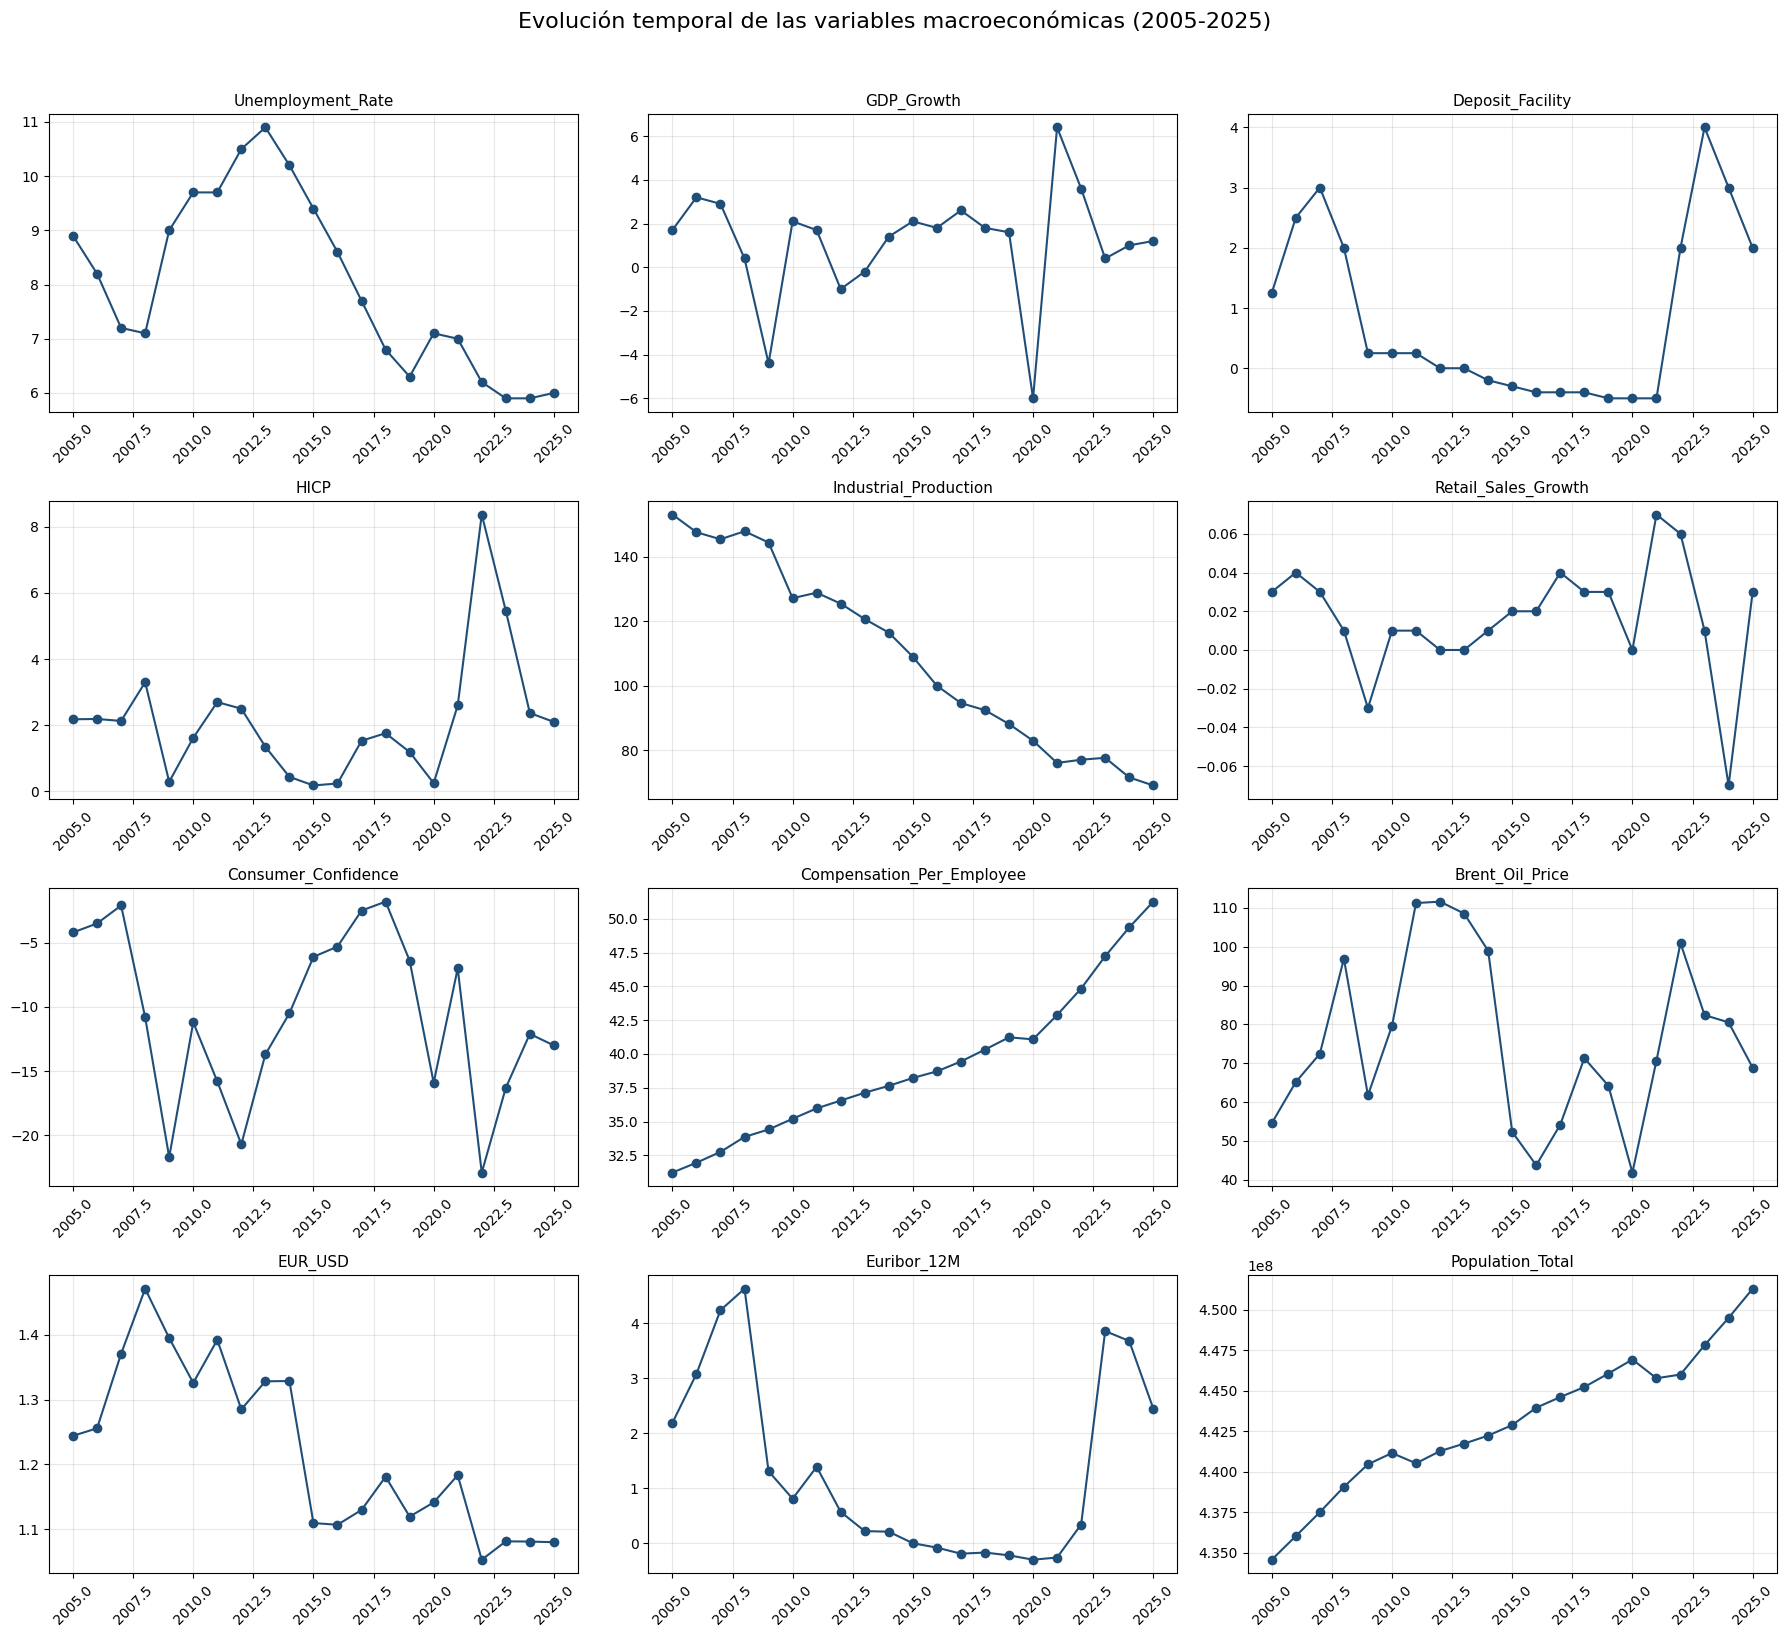

In [ ]:
import matplotlib.pyplot as plt

variables = [
    "Unemployment_Rate", "GDP_Growth", "Deposit_Facility", "HICP",
    "Industrial_Production", "Retail_Sales_Growth", "Consumer_Confidence",
    "Compensation_Per_Employee", "Brent_Oil_Price", "EUR_USD",
    "Euribor_12M", "Population_Total"
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].plot(df["Year"], df[var], marker="o", color="#1F4E79")
    axes[i].set_title(var, fontsize=11)
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Evolución temporal de las variables macroeconómicas (2005-2025)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### `Unemployment_Rate`

Muestra un patrón que aparentemente cíclica. Ya que desciende entre 2005 y
2008 (fase de expansión previa a la crisis) y asciende de forma pronunciada hasta
alcanzar su máximo en 2013 (crisis de deuda soberana). Posteriormente, inicia un
descenso hasta 2025, con la única excepción de un ligero
repunte en 2020-2021 asociado a la pandemia.


---


### `GDP_Growth`

Esta variable oscila constantemente entre valores positivos y negativos. En la serie destacan dos dos mínimos, en 2009 y 2020 seguidas en ambos casos de
recuperaciones rápidas, especialmente tras 2020. El resto del período
se mueve en un rango más moderado, entre 0% y 3% aproximadamente.

---

### `Deposit_Facility`

Presenta una forma de "U" muy marcada. Partiendo de niveles positivos en 2005, desciende
progresivamente hasta estabilizarse en valores negativos durante una larga fase
(aproximadamente 2015-2021), y a partir de 2022 experimenta una subida muy brusca y
pronunciada hasta alcanzar su máximo histórico en 2023, seguida de un descenso en
2024-2025.

---

### `HICP`

Se mantiene relativamente plana y con oscilaciones moderadas (entre 0% y 3,5%)
durante casi todo el período, hasta que en 2022 se produce un pico muy pronunciado y
aislado que la sitúa muy por encima del resto de la serie, para después descender con
la misma rapidez con la que subió, normalizándose en 2023-2025.

---

### `Industrial_Production`

Es una de las variables con la tendencia más clara y sostenida de todo el conjunto:
un descenso prácticamente monótono y constante a lo largo de todo el período, sin
apenas rebotes significativos, cayendo de forma continua desde el inicio hasta el
final de la serie.

---

### `Retail_Sales_Growth`

Se mueve en un rango muy estrecho durante la mayor parte del período, con pequeñas
oscilaciones alrededor de 0. Se aprecian dos caídas puntuales relevantes (2009 y, más
acusada, 2022), así como un pico notable al alza en torno a 2021, coincidiendo con la
recuperación económica postpandemia.

---

### `Consumer_Confidence`

Muestra un patrón muy irregular en forma de "dientes de sierra", con caídas bruscas y
recuperaciones igualmente rápidas. Se identifican claramente cuatro mínimos muy
pronunciados que coinciden con los principales episodios de crisis del período (2009,
2012, 2020 y, de forma especialmente acusada, 2022, el mínimo absoluto de toda la
serie).

---

### `Compensation_Per_Employee`

Es, junto con `Industrial_Production`, la variable con la tendencia más clara: un
crecimiento sostenido, prácticamente lineal y sin interrupciones significativas, a lo
largo de todo el período analizado.

---

### `Brent_Oil_Price`

Presenta la mayor volatilidad de todo el conjunto, con oscilaciones muy amplias y
frecuentes: un máximo relativo en 2011-2012, un descenso pronunciado en 2015-2016,
una caída muy marcada durante la pandemia (2020), y un nuevo pico notable en 2022,
seguido de un descenso hacia el final del período.

---

### `EUR_USD`

Muestra una tendencia descendente a largo plazo, aunque con oscilaciones
significativas: alcanza su máximo en torno a 2008, desciende de forma gradual con
algunos repuntes intermedios (2011, 2018, 2021), y toca su mínimo histórico en 2022,
para después estabilizarse en niveles bajos durante el resto del período.

---

### `Euribor_12M`

Reproduce un patrón muy similar al de `Deposit_Facility` (ambas reflejan la misma
política monetaria): valores elevados antes de 2008, descenso pronunciado y prolongado
hasta terreno negativo entre 2015 y 2021, y una subida muy abrupta a partir de 2022
que alcanza su máximo en 2023, seguida de un descenso hacia 2024-2025.

---

### `Population_Total`

Es la variable más estable y predecible de todo el conjunto: un crecimiento suave,
sostenido y prácticamente lineal a lo largo de todo el período, sin apenas
oscilaciones ni puntos de inflexión relevantes.

---

### Observación conjunta

Se aprecia con claridad que las variables de política monetaria (`Deposit_Facility`,
`Euribor_12M`) presentan una evolución prácticamente idéntica en su forma, lo que
podría indicar una correlación muy elevada entre ambas. Asimismo, durante los años 2008-2009, 2020 y 2022 aparecen sistemáticamente
como puntos de inflexión en la mayoría de las variables (`GDP_Growth`,
`Unemployment_Rate`, `Consumer_Confidence`, `HICP`, `Deposit_Facility`), lo que
confirma que estos episodios de crisis afectaron de forma transversal a todo el
entorno macroeconómico europeo durante el período analizado.

# Matriz de correlación entre variables macroeconómicas



---



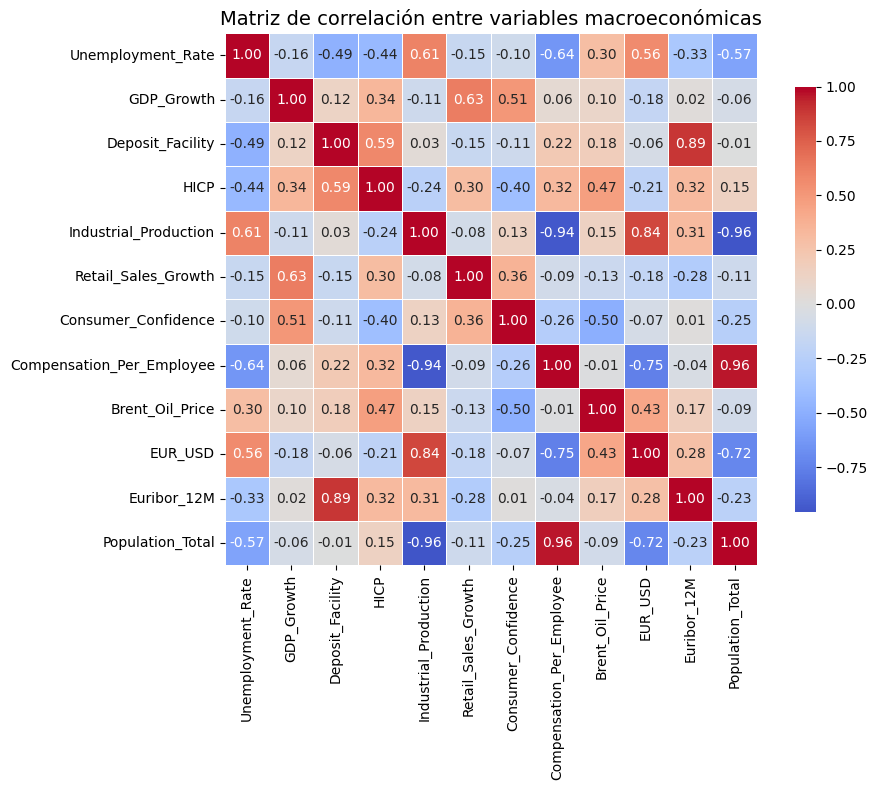

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 8))
corr_matrix = df[variables].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación entre variables macroeconómicas", fontsize=14)
plt.tight_layout()
plt.show()

## Interpretación de la matriz de correlación entre variables macroeconómicas

El análisis de la matriz de correlación de Pearson entre las 12 variables
macroeconómicas permite identificar tanto relaciones esperables desde el punto de
vista teórico como varios casos de multicolinealidad relevante que conviene tener en
cuenta antes de la fase de modelización.

---

### Correlaciones muy fuertes (|r| > 0,85): posible multicolinealidad alta

- **`Compensation_Per_Employee` – `Population_Total` (r = 0,96)**: correlación
  extremadamente alta. Ambas variables comparten una tendencia estructural creciente y
  suave a lo largo de todo el período, lo que las hace prácticamente redundantes entre
  sí desde el punto de vista estadístico, aunque conceptualmente midan cosas distintas
  (salarios vs. tamaño poblacional).

- **`Industrial_Production` – `Population_Total` (r = -0,96)**: correlación negativa
  casi perfecta. Se explica porque ambas son series con tendencias estructurales
  opuestas y sin apenas ruido cíclico (una decreciente, otra creciente), más que por
  una relación causal directa entre ambos fenómenos.

- **`Industrial_Production` – `Compensation_Per_Employee` (r = -0,94)**: en la misma
  línea que el caso anterior, ambas variables muestran tendencias estructurales
  opuestas y muy sostenidas en el tiempo.

- **`Deposit_Facility` – `Euribor_12M` (r = 0,89)**: correlación muy elevada,
  totalmente esperable, ya que ambas variables reflejan el mismo ciclo de política
  monetaria del Banco Central Europeo, como ya se había anticipado al observar la
  similitud de sus gráficos de evolución temporal.

---

### Correlaciones fuertes (0,70 ≤ |r| < 0,85)

- **`Industrial_Production` – `EUR_USD` (r = 0,84)**: ambas variables comparten una
  tendencia descendente a lo largo del período, aunque no existe una relación causal
  directa evidente entre producción industrial y tipo de cambio; es probable que
  ambas respondan de forma parecida a la evolución general del ciclo económico europeo.

- **`Compensation_Per_Employee` – `EUR_USD` (r = -0,75)**: relación inversa notable,
  en la misma línea que la anterior.

- **`EUR_USD` – `Population_Total` (r = -0,72)**: relación inversa fuerte, también
  explicable por tendencias estructurales opuestas más que por una relación
  económica directa.

---

### Correlaciones moderadas (0,50 ≤ |r| < 0,70)

- **`Unemployment_Rate` – `Industrial_Production` (r = 0,61)**: relación positiva
  moderada, algo contraintuitiva a priori (cabría esperar que a mayor producción
  industrial, menor desempleo), que probablemente responda de nuevo a que ambas
  variables comparten tendencias de largo plazo (el desempleo desciende mientras la
  producción industrial también desciende, pero en periodos distintos del ciclo).

- **`Unemployment_Rate` – `Compensation_Per_Employee` (r = -0,64)**: relación inversa
  coherente con la teoría económica: a menor desempleo (mayor tensión en el mercado
  laboral), mayores salarios nominales.

- **`Retail_Sales_Growth` – `GDP_Growth` (r = 0,63)**: relación positiva coherente,
  ya que ambas variables reflejan el dinamismo del consumo y la actividad económica.

- **`Deposit_Facility` – `HICP` (r = 0,59)**: relación positiva razonable, coherente
  con la respuesta del BCE de subir tipos de interés ante episodios de inflación
  elevada (como el observado en 2022).

- **`Unemployment_Rate` – `HICP` (r = -0,44) y `Unemployment_Rate` –
  `Deposit_Facility` (r = -0,49)**: relaciones inversas moderadas, también coherentes
  con la teoría del ciclo económico.

- **`Consumer_Confidence` – `Brent_Oil_Price` (r = -0,50)**: relación inversa
  moderada, razonable dado que un encarecimiento del petróleo suele ir acompañado de
  mayor incertidumbre económica y menor confianza del consumidor.

---

### Correlaciones débiles o prácticamente nulas (|r| < 0,20)

Variables como `Retail_Sales_Growth`, `Consumer_Confidence` o `Brent_Oil_Price`
muestran, en general, correlaciones bajas con la mayoría del resto de variables, lo
que sugiere que aportan información relativamente independiente y complementaria al
conjunto de predictores, en lugar de ser redundantes con otras variables ya incluidas.

---

### Implicaciones para la fase de modelado

El análisis revela un **grupo de variables con tendencias estructurales muy marcadas**
(`Industrial_Production`, `Compensation_Per_Employee`, `Population_Total`, `EUR_USD`)
que están altamente correlacionadas entre sí, principalmente por compartir una
evolución monótona a lo largo del período (creciente o decreciente), más que por una
relación económica directa y causal entre ellas. Asimismo, se confirma la fuerte
relación esperada entre `Deposit_Facility` y `Euribor_12M`, ambas ligadas al mismo
instrumento de política monetaria.

Esta multicolinealidad no representa un problema para el rendimiento predictivo de
modelos basados en árboles como Random Forest, pero sí puede **diluir la importancia
individual** asignada a cada una de estas variables correlacionadas entre sí, ya que
el modelo puede repartir el poder explicativo entre varias variables redundantes en
lugar de concentrarlo en una sola. Este aspecto se tendrá en cuenta al interpretar los
resultados de importancia de variables en el apartado siguiente.

# Relación con las ventas de BMW


---



In [ ]:
df_ventas = pd.read_csv("/content/drive/MyDrive/TFG_BMW/datasets/ventas_bmw.csv")
df_merged = pd.merge(df_ventas, df, left_on="Año", right_on="Year")
df_merged = df_merged.drop(columns=["Year"])

df_merged.head()

,Año,Ventas_BMW_Unidades,Unemployment_Rate,GDP_Growth,Deposit_Facility,HICP,Industrial_Production,Retail_Sales_Growth,Consumer_Confidence,Compensation_Per_Employee,Brent_Oil_Price,EUR_USD,Euribor_12M,Population_Total
0,2005,1126768,8.9,1.7,1.25,2.18,153.2,0.03,-4.2,31.22,54.57,1.2441,2.19,434585887
1,2006,1185088,8.2,3.2,2.50,2.19,147.7,0.04,-3.5,31.95,65.16,1.2556,3.08,436041018
2,2007,1276793,7.2,2.9,3.00,2.13,145.5,0.03,-2.1,32.75,72.44,1.3705,4.24,437514477
3,2008,1202239,7.1,0.4,2.00,3.30,148.0,0.01,-10.8,33.86,96.94,1.4708,4.63,439074280
4,2009,1068770,9.0,-4.4,0.25,0.29,144.5,-0.03,-21.7,34.41,61.74,1.3948,1.31,440467898


In [ ]:
correlaciones = df_merged[["Ventas_BMW_Unidades"] + variables].corr()["Ventas_BMW_Unidades"].drop("Ventas_BMW_Unidades")
correlaciones = correlaciones.sort_values(ascending=False)

correlaciones

,Ventas_BMW_Unidades
Population_Total,0.891348
Compensation_Per_Employee,0.858315
GDP_Growth,0.171654
HICP,0.161310
Retail_Sales_Growth,0.143445
Consumer_Confidence,0.025838
Deposit_Facility,-0.097060
Brent_Oil_Price,-0.167470
Euribor_12M,-0.362991
Unemployment_Rate,-0.550192


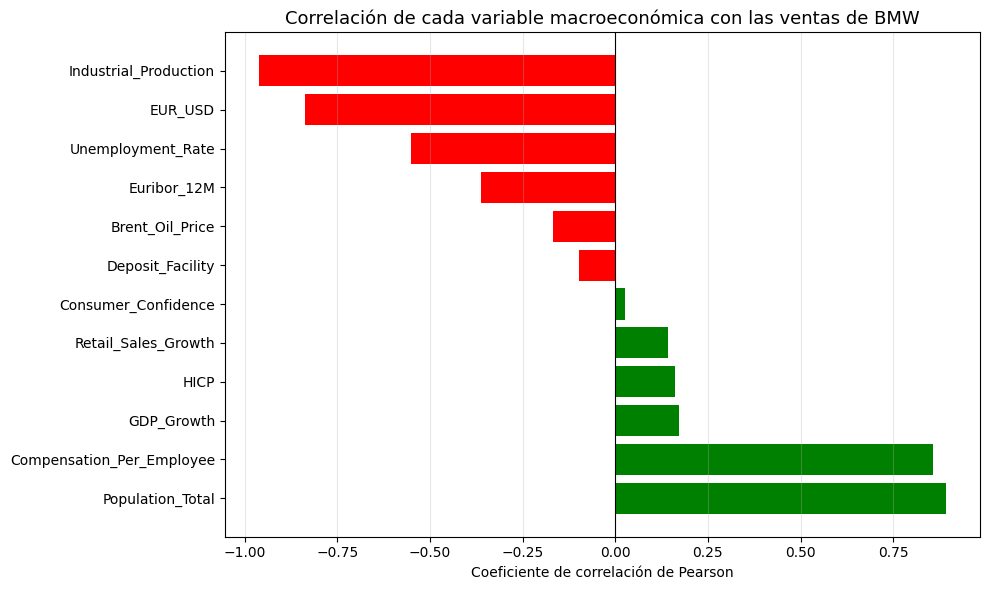

In [ ]:
plt.figure(figsize=(10, 6))
colors = ["green" if v >= 0 else "red" for v in correlaciones.values]
plt.barh(correlaciones.index, correlaciones.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlación de cada variable macroeconómica con las ventas de BMW", fontsize=13)
plt.xlabel("Coeficiente de correlación de Pearson")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## Correlación de las variables macroeconómicas con las ventas de BMW

El análisis de correlación de Pearson entre cada variable macroeconómica y las ventas
de BMW (`Ventas_BMW_Unidades`) revela relaciones de intensidad muy diversa, desde
correlaciones prácticamente nulas hasta relaciones extremadamente fuertes tanto
positivas como negativas.

---

### Correlaciones muy fuertes (|r| > 0,80)

- **`Industrial_Production` (r = -0,96)**: correlación negativa casi perfecta, la más
  fuerte de todo el conjunto. A priori resulta contraintuitivo (cabría esperar una
  relación positiva entre producción industrial y ventas), pero se explica porque
  ambas variables muestran tendencias estructurales opuestas y muy sostenidas a lo
  largo del período. Ya que la producción industrial desciende de forma prácticamente
  monótona mientras las ventas de BMW crecen de forma sostenida. Es, por tanto, más
  un reflejo de tendencias temporales coincidentes que una relación causal directa.

- **`Population_Total` (r = 0,89)**: correlación positiva muy fuerte, también
  explicable en gran medida por la tendencia estructural compartida (ambas variables
  crecen de forma sostenida a lo largo del período), más que por un efecto directo del
  crecimiento demográfico sobre la demanda de vehículos en el corto plazo.

- **`EUR_USD` (r = -0,84)**: correlación negativa muy fuerte. El euro se ha
  depreciado frente al dólar a lo largo del período mientras las ventas de BMW han
  crecido, lo que de nuevo apunta a una coincidencia de tendencias temporales más que
  a una relación económica directa evidente.

---

### Correlación fuerte (0,70 ≤ |r| < 0,80)

- **`Compensation_Per_Employee` (r = 0,86)**: correlación positiva muy fuerte,
  coherente con la teoría económica (a mayor renta disponible, mayor capacidad de
  compra de bienes de gama alta como los vehículos BMW), aunque también fuertemente
  influenciada por tratarse de dos series con tendencia creciente sostenida.

---

### Correlación moderada (0,50 ≤ |r| < 0,70)

- **`Unemployment_Rate` (r = -0,55)**: relación inversa moderada, debido a que mayor desempleo, sugiera una menor capacidad adquisitiva y por tanto, una menor demanda de vehículos.

---

### Correlaciones débiles (|r| < 0,40)

El resto de variables —`Euribor_12M` (-0,36), `Brent_Oil_Price` (-0,17),
`Deposit_Facility` (-0,10), `Consumer_Confidence` (0,03), `Retail_Sales_Growth`
(0,14), `HICP` (0,16) y `GDP_Growth` (0,17)— presentan correlaciones lineales muy
débiles o prácticamente nulas con las ventas de BMW.

Destacan los casos de `GDP_Growth`, `Consumer_Confidence` y
`Euribor_12M`, ya que, la literatura económica señala como determinantes
teóricos importantes de la demanda de bienes duraderos, pero que aquí muestran una
correlación lineal muy baja con las ventas.

---

## Interpretación y cautelas metodológicas

Estos resultados deben interpretarse con **especial cautela** debido a diversas razones:

1. **La correlación no implica causalidad, y menos aún con series temporales de
   tendencia**: las correlaciones más elevadas (`Industrial_Production`,
   `Population_Total`, `EUR_USD`, `Compensation_Per_Employee`) corresponden
   precisamente a las variables con una tendencia más marcada y sostenida a lo largo
   del tiempo. Dado que las ventas de BMW también muestran una tendencia creciente
   clara durante el período, es esperable que cualquier variable con tendencia
   temporal fuerte (al alza o a la baja) presente una correlación elevada con las
   ventas, sin que ello implique necesariamente una relación económica causal directa
   entre ambas.

2. **Variables teóricamente relevantes con baja correlación lineal**: el hecho de que
   `GDP_Growth`, `Consumer_Confidence` o `Deposit_Facility` muestren correlaciones
   bajas no significa que carezcan de relevancia explicativa, sino que su relación con
   las ventas podría ser **no lineal**, estar sujeta a **efectos de retardo temporal**
   (el impacto de una subida de tipos podría notarse en las ventas con uno o dos años
   de desfase, por ejemplo), o depender de **interacciones con otras variables** que
   la correlación de Pearson, al ser una medida bivariante, no es capaz de capturar.

3. **Tamaño muestral reducido**: con solo 21 observaciones anuales, los coeficientes
   de correlación tienen una **robustez estadística limitada**, y pequeñas variaciones
   en los datos podrían alterar sensiblemente estos resultados.

# Diagnóstico de multicolineidad


---



In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_merged[variables]
vif_data = pd.DataFrame()
vif_data["Variable"] = variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(variables))]
vif_data.sort_values("VIF", ascending=False)

,Variable,VIF
11,Population_Total,8382.314361
7,Compensation_Per_Employee,2993.121337
9,EUR_USD,1621.202403
4,Industrial_Production,750.901639
0,Unemployment_Rate,278.567501
8,Brent_Oil_Price,123.855156
10,Euribor_12M,52.978724
3,HICP,40.244758
6,Consumer_Confidence,38.869256
2,Deposit_Facility,31.568456


## Interpretación del análisis de multicolinealidad (VIF)

El **Factor de Inflación de la Varianza (VIF)** cuantifica en qué medida la varianza
de cada variable puede explicarse a partir de una combinación lineal del resto de
variables predictoras. Como referencia general, se utilizarán los siguientes
umbrales:

- **VIF < 5**: sin problema relevante de multicolinealidad.
- **5 ≤ VIF < 10**: multicolinealidad moderada, que conviene vigilar.
- **VIF ≥ 10**: multicolinealidad severa.

Los resultados obtenidos muestran niveles de multicolinealidad **demasiado
elevados** para la mayoría de las variables del conjunto, muy por encima del umbral
habitual de referencia (VIF = 10):

### Multicolinealidad con valores extremadamente altos (VIF > 500)

- **`Population_Total` (VIF = 8.382,3)**, **`Compensation_Per_Employee`**
  (VIF = 2.993,1), **`EUR_USD`** (VIF = 1.621,2) e **`Industrial_Production`**
  (VIF = 750,9) presentan valores de VIF muy altos, muy por encima de
  cualquier umbral de referencia habitual. Lo que confirma lo
  observado tanto en la matriz de correlación como en el análisis de correlación con
  las ventas: estas cuatro variables comparten en gran medida la misma información
  (tendencias estructurales muy marcadas y sostenidas a lo largo del período), hasta
  ser prácticamente combinaciones lineales unas de otras.

---

### Multicolinealidad muy alta (50 < VIF < 300)

- **`Unemployment_Rate`** (VIF = 278,6), **`Brent_Oil_Price`** (VIF = 123,9) y
  **`Euribor_12M`** (VIF = 53,0) presentan también niveles de multicolinealidad muy
  elevados, aunque considerablemente menores que el grupo anterior.

---

### Multicolinealidad alta (10 < VIF < 50)

- **`HICP`** (VIF = 40,2), **`Consumer_Confidence`** (VIF = 38,9) y
  **`Deposit_Facility`** (VIF = 31,6) superan también el umbral de multicolinealidad
  de las variables anteriores aunque de menor manera.

---

### Únicas variables sin multicolinealidad relevante (VIF < 10)

- **`GDP_Growth`** (VIF = 6,3) y **`Retail_Sales_Growth`** (VIF = 5,0) son las únicas
  dos variables del conjunto con niveles de VIF por debajo del umbral estándar de
  multicolinealidad severa (aunque `GDP_Growth` se sitúa ligeramente por encima del
  umbral de 5 para multicolinealidad moderada).

---

## Explicación de la magnitud de estos valores

Los valores de VIF obtenidos son considerablemente más altos de lo habitual en
estudios econométricos convencionales. Esto se debe fundamentalmente a dos factores
propios del diseño de este conjunto de datos:

1. **Tamaño muestral muy reducido en relación al número de predictores** (21
   observaciones frente a 12 variables): el VIF es extremadamente sensible al tamaño
   muestral, y con tan pocas observaciones cualquier combinación lineal aproximada
   entre variables se ve amplificada de forma muy notable.

2. **Predominio de series con tendencia temporal fuerte**: la mayoría de las
   variables del conjunto (`Population_Total`, `Compensation_Per_Employee`,
   `Industrial_Production`, `EUR_USD`, `Unemployment_Rate`) no son series
   estacionarias, sino que presentan una tendencia sostenida (creciente o
   decreciente) a lo largo de los 21 años analizados.
   
   Cuando varias variables no
   estacionarias se incluyen conjuntamente en un modelo, es habitual obtener valores
   de VIF muy elevados, ya que gran parte de su varianza puede explicarse
   simplemente por la variable temporal subyacente («Año»), común a todas ellas.

---

## Implicaciones para la fase de modelado

Estos resultados refuerzan la necesidad de interpretar con cautela la importancia
individual de las variables en el modelo de Random Forest del cuaderno siguiente,
especialmente en el caso de `Population_Total`, `Compensation_Per_Employee`,
`EUR_USD` e `Industrial_Production`. Dado que estas variables comparten una parte muy
sustancial de su información, es previsible que el modelo reparta su importancia
predictiva entre ellas de forma poco estable, sin que el resultado permita atribuir de
forma inequívoca el efecto observado a una variable concreta.

Cabe destacar que esta limitación es coherente con la detectada previamente en el
análisis de correlación con las ventas de BMW, donde precisamente estas mismas
variables (`Industrial_Production`, `Population_Total`, `EUR_USD`,
`Compensation_Per_Employee`) presentaban las correlaciones más elevadas con la
variable objetivo. Lo que refuerza la hipótesis de que dichas correlaciones responden en
gran medida a tendencias temporales compartidas más que a relaciones económicas
causales directas.

# Comprobación final de valores nulos


---



In [ ]:
print("Valores nulos en el dataset combinado:")
print(df_merged.isnull().sum())
print("\nFilas duplicadas:", df_merged.duplicated().sum())

Valores nulos en el dataset combinado:
Año                          0
Ventas_BMW_Unidades          0
Unemployment_Rate            0
GDP_Growth                   0
Deposit_Facility             0
HICP                         0
Industrial_Production        0
Retail_Sales_Growth          0
Consumer_Confidence          0
Compensation_Per_Employee    0
Brent_Oil_Price              0
EUR_USD                      0
Euribor_12M                  0
Population_Total             0
dtype: int64

Filas duplicadas: 0


# Bibliografía

---

## Ventas de BMW

**BMW Group Annual Reports**

| Año  | Informe                                                      |
|------|---------------------------------------------------------------|
| 2005 | BMW Group Annual Report 2005                                  |
| 2006 | BMW Group Annual Report 2006                                  |
| 2007 | BMW Group Annual Report 2007                                  |
| 2008 | BMW Group Annual Report 2008 *(Investor Relations Archive)*   |
| 2009 | BMW Group Annual Report 2009 *(Investor Relations Archive)*   |
| 2010 | BMW Group Annual Report 2010 *(Investor Relations Archive)*   |
| 2011 | BMW Group Annual Report 2011 *(Investor Relations Archive)*   |
| 2012 | BMW Group Annual Report 2012 *(Investor Relations Archive)*   |
| 2013 | BMW Group Annual Report 2013 *(Investor Relations Archive)*   |
| 2014 | BMW Group Annual Report 2014 *(Investor Relations Archive)*   |
| 2015 | BMW Group Annual Report 2015 *(Investor Relations Archive)*   |
| 2016 | BMW Group Annual Report 2016 *(Investor Relations Archive)*   |
| 2017 | BMW Group Annual Report 2017 *(Investor Relations Archive)*   |
| 2018 | BMW Group Annual Report 2018 *(Investor Relations Archive)*   |
| 2019 | BMW Group Annual Report 2019 *(Investor Relations Archive)*   |
| 2020 | BMW Group Report 2020                                         |
| 2021 | BMW Group Report 2021 *(Investor Relations Archive)*           |
| 2022 | BMW Group Report 2022 *(Investor Relations Archive)*           |
| 2023 | BMW Group Report 2023 *(Investor Relations Archive)*           |
| 2024 | BMW Group Report 2024                                         |
| 2025 | BMW Group Report 2025                                         |

---

## Variables macroeconómicas

**Tasa de desempleo**
Eurostat — *Unemployment by sex and age, annual data*
- https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Unemployment_statistics
- https://ec.europa.eu/eurostat/databrowser/view/UNE_RT_M__custom_118016/bookmark/table?lang=en&bookmarkId=efcf7c9f-c4d7-4bc2-8c74-962ead60acfc&c=1603730430589

**Crecimiento del PIB**
Datos Macro — *Evolución del PIB anual en la eurozona*
- https://datosmacro.expansion.com/pib/zona-euro

**Tipo de depósito del BCE**
Banco Central Europeo — *Key ECB interest rates (Deposit facility)*
- https://www.ecb.europa.eu/stats/policy_and_exchange_rates/key_ecb_interest_rates/html/index.es.html

**Inflación (HICP)**
Banco Central Europeo — *HICP Inflation rate – Total – Annual rate of change, Euro area, Monthly*
- https://www.ecb.europa.eu/stats/macroeconomic_and_sectoral/hicp/more/html/data.es.html

**Población total**
Eurostat — *Population change – Demographic balance and crude rates at national level*
- https://ec.europa.eu/eurostat/databrowser/view/demo_gind__custom_17386652/bookmark/table?lang=en&bookmarkId=1c4b8145-a6e5-48a5-afe4-e2b4e983c485&c=1752064755805

**Producción industrial**
Eurostat — *Production in industry – annual data (sts_inpr_a)*
- https://ec.europa.eu/eurostat/web/short-term-business-statistics/database

**Ventas minoristas**
Eurostat — *Turnover and volume of sales in wholesale and retail trade – monthly data*
- https://ec.europa.eu/eurostat/databrowser/view/sts_trtu_m__custom_22295106/default/table

**Tipo de cambio EUR/USD**
Banco Central Europeo — *Evolución anual media tipo de cambio EUR/USD (dataset EXR)*
- https://data.ecb.europa.eu/data/datasets/EXR/EXR.A.USD.EUR.SP00.A

**Precio del petróleo Brent**
U.S. Energy Information Administration (EIA) — *Evolución anual petróleo Brent Europa*
- https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=RBRTE&f=A

**Euríbor a 12 meses**
- https://www.euribordiario.es
- https://www.bancsabadell.com/bsnacional/es/particulares/hipotecas/euribor/

**Compensación por empleado**
AMECO (Comisión Europea) — *Nominal compensation per employee: total economy*
- https://db.nomics.world/AMECO/HWCDW?offset=10&tab=list

**Confianza del consumidor**
Comisión Europea — *Main Indicators (ESI, EEI, sectoral CIs)*
- https://economy-finance.ec.europa.eu/economic-forecast-and-surveys/business-and-consumer-surveys/download-business-and-consumer-survey-data/time-series_en